In [35]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

#### Functions

In [36]:
def evaluate_model(model, X_test, y_test):
    """
    Avalia um modelo de classificação e exibe métricas detalhadas.

    Args:
      model: Modelo Keras treinado.
      X_test: Dados de teste (features).
      y_test: Rótulos de teste.
    """
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"Loss: {loss:.4f}")
    print(f"Acurácia: {accuracy:.4f}")

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Calculando a matriz de confusão
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_classes).ravel()

    # Calculando as métricas
    tpr = tp / (tp + fn)  # Taxa de verdadeiros positivos (recall)
    tnr = tn / (tn + fp)  # Taxa de verdadeiros negativos
    fnr = fn / (tp + fn)  # Taxa de falsos negativos
    fpr = fp / (tn + fp)  # Taxa de falsos positivos

    precision = tp / (tp + fp)  # Precisão
    recall = tpr  # Recall
    f1 = 2 * (precision * recall) / (precision + recall)  # F1-score
    auc = roc_auc_score(y_test, y_pred_classes)
    
    # Imprimindo as métricas
    print("\nMétricas da Matriz de Confusão:")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")
    print(f"TPR (Recall): {tpr:.4f}")
    print(f"TNR: {tnr:.4f}")
    print(f"FNR: {fnr:.4f}")
    print(f"FPR: {fpr:.4f}")

    print("\nMétricas de Classificação:")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")

    # Matriz de Confusão (visualização)
    print("\nMatriz de Confusão:")
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Previsão")
    plt.ylabel("Verdadeiro")
    plt.title("Matriz de Confusão")
    plt.show()

    print("Relatório de Classificação:")
    print(classification_report(y_test, y_pred_classes))

#### Load Data

In [37]:
df_normal = pd.read_parquet('data/result/normal.parquet')
df_imbalance = pd.read_parquet('data/result/imbalance.parquet')
df_overhang = pd.read_parquet('data/result/overhang.parquet')
df_underhang = pd.read_parquet('data/result/underhang.parquet')
df_horizontal_misalignment= pd.read_parquet('data/result/horizontal-misalignment.parquet')
df_vertical_misalignment = pd.read_parquet('data/result/vertical-misalignment.parquet')

#### TC 1 - Todas anomalias

In [38]:
df_anomaly = pd.concat([df_imbalance, df_overhang, df_underhang, df_horizontal_misalignment, df_vertical_misalignment])

In [39]:
#df['target_desc'].value_counts()

In [40]:
samples_per_class = 245

In [41]:
df_other_subsampled = pd.DataFrame()

for label in df_anomaly['target_desc'].unique():
    df_label = df_anomaly[df_anomaly['target_desc'] == label]
    df_label_subsampled = resample(df_label,
                                 replace=False,
                                 n_samples=samples_per_class,
                                 random_state=42)
    df_other_subsampled = pd.concat([df_other_subsampled, df_label_subsampled])

In [42]:
df_balanced = pd.concat([df_normal, df_other_subsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [43]:
df_balanced['target_desc'].value_counts()


target_desc
underhang_ball_fault       245
overhang_outer_race        245
vertical-misalignment      245
overhang_ball_fault        245
underhang_cage_fault       245
horizontal-misalignment    245
underhang_outer_race       245
normal                     245
overhang_cage_fault        245
imbalance                  245
Name: count, dtype: int64

In [44]:
df_filtrado = df_balanced[df_balanced['target_desc'].isin(['normal', 'vertical-misalignment'])]

In [64]:
df_filtrado['target_desc'].value_counts()


target_desc
horizontal-misalignment    245
normal                     245
Name: count, dtype: int64

In [46]:
X = df_balanced.drop(['target_desc', 'target_parameters', 'target'], axis=1)
y = df_balanced['target']

In [47]:
# Dividir em conjuntos de treinamento, validação e teste
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [48]:
# Supondo que X_train e y_train já estão definidos (sem o reshape para a CNN)

# Treinar uma Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Obter a importância das features
feature_importances = rf_model.feature_importances_

# Criar um DataFrame para visualizar a importância das features
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# Exibir as features mais importantes
print(feature_importance_df)

# Selecionar as N features mais importantes
num_features_to_select = 15  # Defina quantas features você quer selecionar
selected_features = feature_importance_df['feature'][:num_features_to_select].tolist()
n_features = len(selected_features)
input_shape = (n_features, 1)
batch_size = 32  # Ajuste conforme necessário
epochs = 100 # Ajuste conforme necessário
num_classes = len(np.unique(y_train))

                            feature  importance
69   uba_tangencial_shannon_entropy    0.082253
102             oba_radial_kurtosis    0.054526
49       uba_radial_shannon_entropy    0.052809
152           microphone_fft_freq_2    0.041791
115            oba_radial_fft_mag_3    0.024413
..                              ...         ...
148       microphone_peak_frequency    0.000080
128   oba_tangencial_peak_frequency    0.000074
64         uba_tangencial_max_value    0.000032
150           microphone_fft_freq_1    0.000000
10              rot_freq_fft_freq_1    0.000000

[160 rows x 2 columns]


In [49]:
selected_features = [
    'uba_tangencial_shannon_entropy',
    'oba_radial_kurtosis',
    'uba_radial_shannon_entropy',
    'microphone_fft_freq_2',
    'oba_radial_fft_mag_3',
    'uba_axial_shannon_entropy',
    'oba_radial_fft_mag_2',
    'oba_radial_fft_mag_1',
    'microphone_kurtosis',
    'oba_axial_shannon_entropy',
    'uba_axial_kurtosis',
    'oba_radial_std',
    'uba_radial_fft_freq_1',
    'uba_axial_fft_freq_2',
    'oba_tangencial_fft_freq_1'
]

In [50]:
#categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
#categorical_cols

In [51]:
sc = StandardScaler()

# Aplica o StandardScaler em todas as colunas do DataFrame
X_train_ss = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)
X_test_ss = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)
X_val_ss = pd.DataFrame(sc.transform(X_val), columns=X_val.columns)

In [52]:
X_train_ss = X_train_ss[selected_features]
X_test_ss = X_test_ss[selected_features]
X_val_ss = X_val_ss[selected_features]

In [53]:
X_train_reshaped = X_train_ss.values.reshape(X_train_ss.shape[0], n_features, 1)
X_test_reshaped = X_test_ss.values.reshape(X_test_ss.shape[0], n_features, 1)
X_val_reshaped = X_val_ss.values.reshape(X_val_ss.shape[0], n_features, 1)

In [54]:
def create_cnn_model(input_shape, num_classes):
    input_layer = Input(shape=input_shape)

    x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    x = Flatten()(x)
    x = Dense(100, activation='relu')(x)
    x = Dropout(0.2)(x)

    output_layer = Dense(num_classes, activation='softmax')(x)  # Use softmax para classificação multiclasse

    model = Model(inputs=input_layer, outputs=output_layer)

    model.summary()

    model.compile(optimizer = Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

    print("Treinando o modelo CNN...")
    model_history = model.fit(X_train_reshaped, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_val_reshaped, y_val), verbose=0)

    print("\nAvaliando o modelo CNN...")
    evaluate_model(model, X_test_reshaped, y_test)
    
    return model, model_history

In [55]:
def create_rnn_model(input_shape, num_classes):
    """
    Cria um modelo RNN com camadas adicionais para melhorar o desempenho.

    Args:
      input_shape: Forma da entrada (tuple).
      num_classes: Número de classes de saída (int).

    Returns:
      Um modelo Keras compilado.
    """
    input_layer = Input(shape=input_shape)

    # Camadas RNN empilhadas
    x = GRU(64, activation='relu', return_sequences=True)(input_layer)
    x = GRU(32, activation='relu')(x) 

    # Camadas densas adicionais
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    output_layer = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output_layer)
    model.summary()

    model.compile(optimizer = Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    print("Treinando o modelo RNN...")
    model_history = model.fit(X_train_reshaped, y_train,
                            batch_size=batch_size,
                            epochs=epochs,
                            validation_data=(X_val_reshaped, y_val), verbose=0)

    print("\nAvaliando o modelo RNN...")
    evaluate_model(model, X_test_reshaped, y_test)

    return model, model_history

In [56]:
def create_lstm_model(input_shape, num_classes):
    input_layer = Input(shape=input_shape)
    x = LSTM(50, activation='relu')(input_layer)  # Você pode adicionar mais camadas LSTM
    x = Dropout(0.2)(x)
    x = Dense(100, activation='relu')(x)
    x = Dropout(0.2)(x)
    output_layer = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output_layer)

    model.summary()

    model.compile(optimizer = Adam(),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])


    print("Treinando o modelo LSTM...")
    model_history = model.fit(X_train_reshaped, y_train,
                              batch_size=batch_size,
                              epochs=epochs,
                              validation_data=(X_val_reshaped, y_val), verbose=0)

    print("\nAvaliando o modelo LSTM...")
    evaluate_model(model, X_test_reshaped, y_test)
    
    return model, model_history

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 15, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 7, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        19,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,838 (100.93 KB)

 Trainable params: 25,838 (100.93 KB)

 Non-trainable params: 0 (0.00 B)

Treinando o modelo CNN...

Avaliando o modelo CNN...
Loss: 0.0030
Acurácia: 1.0000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Métricas da Matriz de Confusão:
TN: 37
FP: 0
FN: 0
TP: 331
TPR (Recall): 1.0000
TNR: 1.0000
FNR: 0.0000
FPR: 0.0000

Métricas de Classificação:
Acurácia: 1.0000
Precisão: 1.0000
Recall: 1.0000
F1-score: 1.0000
AUC: 1.0000

Matriz de Confusão:


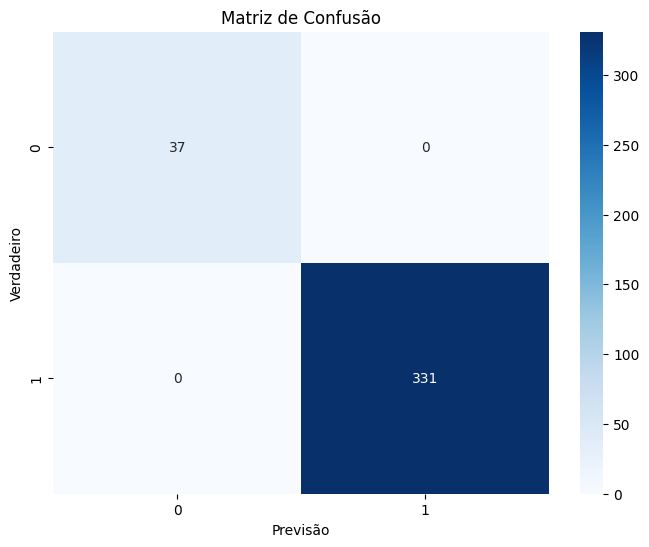

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00       331

    accuracy                           1.00       368
   macro avg       1.00      1.00      1.00       368
weighted avg       1.00      1.00      1.00       368



In [57]:
cnn_model, cnn_model_history = create_cnn_model(input_shape, num_classes)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 15, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 15, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,882 (136.26 KB)

 Trainable params: 34,882 (136.26 KB)

 Non-trainable params: 0 (0.00 B)

Treinando o modelo RNN...

Avaliando o modelo RNN...
Loss: 0.0240
Acurácia: 0.9891
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 

Métricas da Matriz de Confusão:
TN: 36
FP: 1
FN: 3
TP: 328
TPR (Recall): 0.9909
TNR: 0.9730
FNR: 0.0091
FPR: 0.0270

Métricas de Classificação:
Acurácia: 0.9891
Precisão: 0.9970
Recall: 0.9909
F1-score: 0.9939
AUC: 0.9820

Matriz de Confusão:


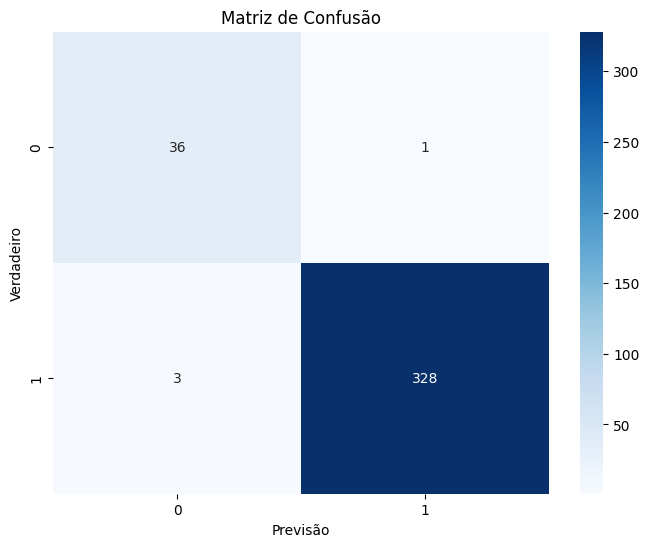

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        37
           1       1.00      0.99      0.99       331

    accuracy                           0.99       368
   macro avg       0.96      0.98      0.97       368
weighted avg       0.99      0.99      0.99       368



In [58]:
rnn_model, rnn_model_history  = create_rnn_model(input_shape, num_classes)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 15, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,702 (61.34 KB)

 Trainable params: 15,702 (61.34 KB)

 Non-trainable params: 0 (0.00 B)

Treinando o modelo LSTM...

Avaliando o modelo LSTM...
Loss: 0.0666
Acurácia: 0.9810
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Métricas da Matriz de Confusão:
TN: 33
FP: 4
FN: 3
TP: 328
TPR (Recall): 0.9909
TNR: 0.8919
FNR: 0.0091
FPR: 0.1081

Métricas de Classificação:
Acurácia: 0.9810
Precisão: 0.9880
Recall: 0.9909
F1-score: 0.9894
AUC: 0.9414

Matriz de Confusão:


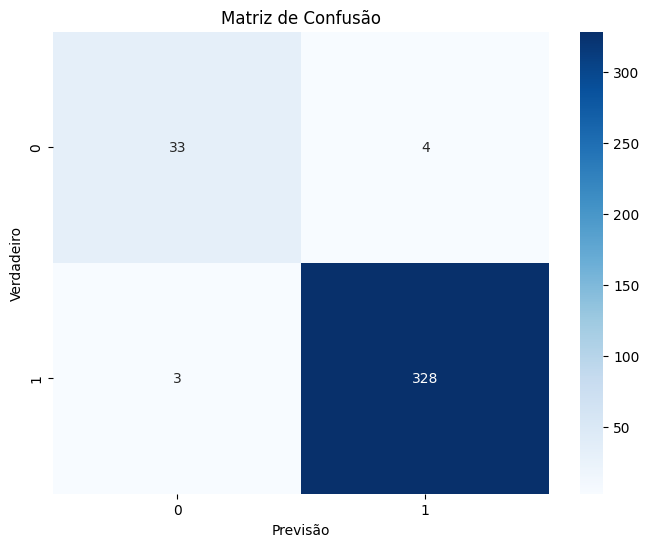

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90        37
           1       0.99      0.99      0.99       331

    accuracy                           0.98       368
   macro avg       0.95      0.94      0.95       368
weighted avg       0.98      0.98      0.98       368



In [60]:
lstm_model, lstm_model_history = create_lstm_model(input_shape, num_classes)

In [61]:
X_train['target'] = y_train
X_val['target'] = y_val
X_test['target'] = y_test

In [66]:
X_train.to_parquet('data/result/exp_3/train.parquet')
X_val.to_parquet('data/result/exp_3/val.parquet')
X_test.to_parquet('data/result/exp_3/test.parquet')